In [1]:
import torch

In [38]:
activations = {'harmful': [], 'harmless': []}
for category in ['harmful', 'harmless']:
    i = 0
    while True:
        end = i + 8
        filename = f'/workspace/refusal-ablation-misalignment/exit_early/activations/{category}/{i}-{end}.pt'
        try:
            batch = torch.load(filename).to('cuda')
            # Append each item in the batch separately
            for item in batch:
                activations[category].append(item)
            i += 8
        except FileNotFoundError:
            break

# Split data into train/val/test (60/20/20) without shuffling
train_data = []
val_data = []
test_data = []

for category in ['harmful', 'harmless']:
    # Get label for this category
    label = 1 if category == 'harmful' else 0
    
    # Calculate split points (60% for training, 20% for validation, 20% for testing)
    total_samples = len(activations[category])
    train_size = int(0.6 * total_samples)
    val_size = int(0.2 * total_samples)
    
    # Split without shuffling and create tuples with labels
    train_split = activations[category][:train_size]
    val_split = activations[category][train_size:train_size + val_size]
    test_split = activations[category][train_size + val_size:]
    
    # Add tuples of (tensor, label) to respective datasets
    for sample in train_split:
        train_data.append((sample, label))
    for sample in val_split:
        val_data.append((sample, label))
    for sample in test_split:
        test_data.append((sample, label))

In [39]:
from torch.utils.data import Dataset, DataLoader

In [40]:
# Create DataLoaders for each dataset
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [41]:
import torch.nn as nn
import torch.optim as optim

# Define a simple logistic regression model
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 2)  # 2 classes for CrossEntropyLoss
    
    def forward(self, x):
        # Flatten the input if it's not already 1D
        out = self.linear(x)
        return out  # No sigmoid needed for CrossEntropyLoss

# Get input dimension from the last dimension of the first sample
input_dim = train_data[0][0].shape[-1]

# Initialize the model
model = LogisticRegression(input_dim).to('cuda')

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model initialized with input dimension: {input_dim}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters())}")


Model initialized with input dimension: 2304
Number of parameters: 4610


In [47]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 15.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 4.9 MB/s eta 0:00:0000:0100:01m

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [66]:
def calculate_log_space_auroc(targets, probs):
    """
    Calculate custom log-space AUROC score with FPR from 1e-3 to 1e-1
    
    Args:
        targets: True binary labels (0 or 1)
        probs: Predicted probabilities for the positive class
    
    Returns:
        log_space_auroc: Custom log-space AUROC score
    """
    from sklearn.metrics import roc_curve
    import numpy as np
    
    fpr, tpr, _ = roc_curve(targets, probs)
    
    # Define FPR range in log space from 1e-3 to 1e-1
    fpr_log_range = np.logspace(-3, -1, 100)  # 100 points from 1e-3 to 1e-1
    
    # Interpolate TPR values at the specified FPR points
    # Only consider FPR values within our range
    valid_mask = (fpr >= 1e-3) & (fpr <= 1e-1)
    if np.any(valid_mask):
        # Interpolate TPR for the log-spaced FPR values
        tpr_interp = np.interp(fpr_log_range, fpr[valid_mask], tpr[valid_mask])
        # Calculate AUC using trapezoidal rule in log space
        # We integrate TPR with respect to log(FPR)
        log_fpr = np.log10(fpr_log_range)
        log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))
    else:
        # If no points in range, return 0
        log_space_auroc = 0.0
    
    return log_space_auroc


def evaluate_model(model, data_loader, criterion, layer_idx=0):
    """
    Evaluate the model on a given dataset
    
    Args:
        model: The neural network model
        data_loader: DataLoader for the dataset to evaluate
        criterion: Loss function
        layer_idx: Which layer to use for classification (default: 0)
    
    Returns:
        avg_loss: Average loss on the dataset
        accuracy: Accuracy percentage on the dataset
        log_space_auroc: Custom log-space AUROC score with FPR from 1e-3 to 1e-1
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to('cuda'), target.to('cuda')
            # Extract the specified layer: data shape is (batch, n_layers, d_model)
            layer_data = data[:, layer_idx, :]  # Shape: (batch, d_model)
            output = model(layer_data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
            
            # Store for ROC calculation
            probs = torch.softmax(output, dim=1)[:, 1]  # Get probability of positive class
            all_targets.extend(target.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(data_loader)
    accuracy = 100 * correct / total
    
    # Calculate custom log-space AUROC using the separate function
    log_space_auroc = calculate_log_space_auroc(all_targets, all_probs)
    
    return avg_loss, accuracy, log_space_auroc


def train_model(model, train_loader, val_loader, criterion, lr=0.001, n_epochs=10, layer_idx=0):
    """
    Train the model with specified learning rate and number of epochs
    
    Args:
        model: The neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        criterion: Loss function
        lr: Learning rate (default: 0.001)
        n_epochs: Number of epochs to train (default: 10)
        layer_idx: Which layer to use for classification (default: 0)
    
    Returns:
        train_losses: List of training losses per epoch
        val_losses: List of validation losses per epoch
        train_accuracies: List of training accuracies per epoch
        val_accuracies: List of validation accuracies per epoch
        val_log_space_aurocs: List of validation log-space AUROC scores per epoch
    """
    # Initialize optimizer with specified learning rate
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Lists to store metrics
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    val_log_space_aurocs = []
    
    for epoch in range(n_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to('cuda'), target.to('cuda')
            # Extract the specified layer: data shape is (batch, n_layers, d_model)
            layer_data = data[:, layer_idx, :]  # Shape: (batch, d_model)
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            output = model(layer_data)
            loss = criterion(output, target)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            # Calculate statistics
            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        # Calculate average training metrics
        avg_train_loss = train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        
        # Validation phase using the separate evaluation function
        val_loss, val_accuracy, val_log_space_auroc = evaluate_model(model, val_loader, criterion, layer_idx)
        
        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        val_log_space_aurocs.append(val_log_space_auroc)
        
        # Print progress
        print(f'Epoch [{epoch+1}/{n_epochs}] - '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% - '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%, Val Log-Space AUROC: {val_log_space_auroc:.4f}')
    
    return train_losses, val_losses, train_accuracies, val_accuracies, val_log_space_aurocs

# Example usage:
# train_losses, val_losses, train_accs, val_accs, val_log_space_aurocs = train_model(
#     model, train_loader, val_loader, criterion, lr=0.001, n_epochs=20, layer_idx=0
# )


/tmp/ipykernel_13684/3475797898.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))
/tmp/ipykernel_13684/3475797898.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))


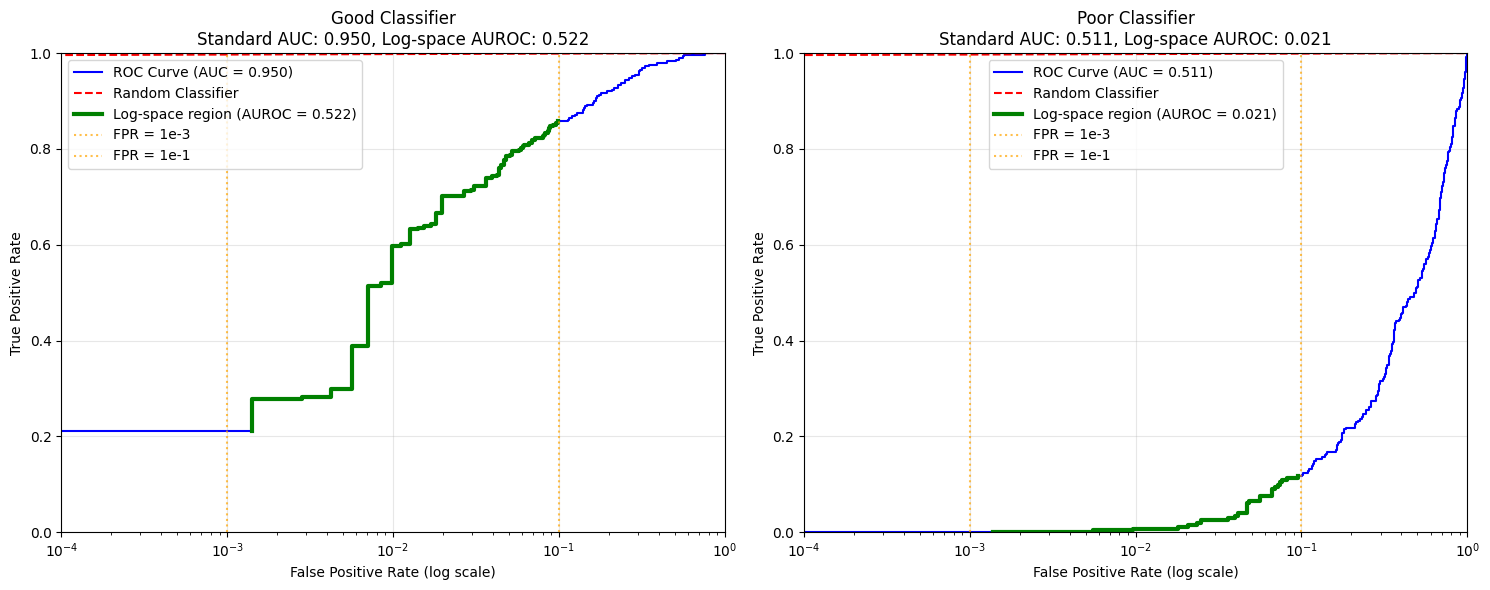

Test Results:
Good classifier - Standard AUC: 0.511, Log-space AUROC: 0.522
Poor classifier - Standard AUC: 0.511, Log-space AUROC: 0.021


/tmp/ipykernel_13684/3475797898.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))
/tmp/ipykernel_13684/3475797898.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))


In [67]:
# Test the log-space AUROC function with a plot
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

# Generate synthetic test data
np.random.seed(42)
n_samples = 1000

# Create some example data with different discrimination abilities
# Case 1: Good classifier
good_targets = np.random.binomial(1, 0.3, n_samples)
good_probs = np.where(good_targets == 1, 
                     np.random.beta(3, 1, n_samples),  # Higher probs for positive class
                     np.random.beta(1, 3, n_samples))  # Lower probs for negative class

# Case 2: Poor classifier (more random)
poor_targets = np.random.binomial(1, 0.3, n_samples)
poor_probs = np.random.beta(2, 2, n_samples)  # More uniform distribution

# Calculate ROC curves and metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (targets, probs, title) in enumerate([
    (good_targets, good_probs, "Good Classifier"),
    (poor_targets, poor_probs, "Poor Classifier")
]):
    
    # Calculate standard ROC curve
    fpr, tpr, _ = roc_curve(targets, probs)
    standard_auc = auc(fpr, tpr)
    
    # Calculate our custom log-space AUROC
    log_space_auroc = calculate_log_space_auroc(targets, probs)
    
    # Plot ROC curve
    axes[i].plot(fpr, tpr, 'b-', label=f'ROC Curve (AUC = {standard_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], 'r--', label='Random Classifier')
    
    # Highlight the log-space region
    log_region_mask = (fpr >= 1e-3) & (fpr <= 1e-1)
    if np.any(log_region_mask):
        axes[i].plot(fpr[log_region_mask], tpr[log_region_mask], 'g-', linewidth=3, 
                    label=f'Log-space region (AUROC = {log_space_auroc:.3f})')
    
    # Mark the boundaries of our log-space region
    axes[i].axvline(x=1e-3, color='orange', linestyle=':', alpha=0.7, label='FPR = 1e-3')
    axes[i].axvline(x=1e-1, color='orange', linestyle=':', alpha=0.7, label='FPR = 1e-1')
    
    axes[i].set_xlim([1e-4, 1])
    axes[i].set_ylim([0, 1])
    axes[i].set_xscale('log')
    axes[i].set_xlabel('False Positive Rate (log scale)')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'{title}\nStandard AUC: {standard_auc:.3f}, Log-space AUROC: {log_space_auroc:.3f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Test Results:")
print(f"Good classifier - Standard AUC: {auc(fpr, tpr):.3f}, Log-space AUROC: {calculate_log_space_auroc(good_targets, good_probs):.3f}")
print(f"Poor classifier - Standard AUC: {auc(*roc_curve(poor_targets, poor_probs)[:2]):.3f}, Log-space AUROC: {calculate_log_space_auroc(poor_targets, poor_probs):.3f}")


In [63]:
# Test training the model with suitable hyperparameters across different layers
print("Starting model training across multiple layers...")

import pandas as pd

# Set hyperparameters
learning_rate = 0.001
num_epochs = 15
batch_size = 64  # Should match the batch size used in data loaders

# Initialize results storage
results = []

# Train models for each layer from 0 to 25
for layer_idx in range(15,20,1):  # 0 to 25 inclusive
    print(f"\n{'='*50}")
    print(f"Training model for layer {layer_idx}")
    print(f"{'='*50}")
    
    # Initialize the model, criterion, and optimizer for this layer
    model = LogisticRegression(2304).to('cuda')
    criterion = nn.CrossEntropyLoss()
    
    # Train the model
    train_losses, val_losses, train_accs, val_accs, val_roc_aucs = train_model(
        model, train_loader, val_loader, criterion, 
        lr=learning_rate, n_epochs=num_epochs, layer_idx=layer_idx
    )
    
    # Store results for this layer
    results.append({
        'layer_idx': layer_idx,
        'final_train_accuracy': train_accs[-1],
        'final_val_accuracy': val_accs[-1],
        'final_val_roc_auc': val_roc_aucs[-1],
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'best_val_accuracy': max(val_accs),
        'best_val_roc_auc': max(val_roc_aucs)
    })
    
    print(f"Layer {layer_idx} - Final Train Acc: {train_accs[-1]:.2f}%, Final Val Acc: {val_accs[-1]:.2f}%, Final Val ROC AUC: {val_roc_aucs[-1]:.4f}")

# Create DataFrame with results
results_df = pd.DataFrame(results)

print(f"\n{'='*60}")
print("Training completed for all layers!")
print(f"{'='*60}")
print("\nResults Summary:")
print(results_df.to_string(index=False))

# Display best performing layers
best_val_acc_layer = results_df.loc[results_df['final_val_accuracy'].idxmax()]
best_val_auc_layer = results_df.loc[results_df['final_val_roc_auc'].idxmax()]

print(f"\nBest Final Validation Accuracy: {best_val_acc_layer['final_val_accuracy']:.2f}% at layer {best_val_acc_layer['layer_idx']}")
print(f"Best Final Validation ROC AUC: {best_val_auc_layer['final_val_roc_auc']:.4f} at layer {best_val_auc_layer['layer_idx']}")


Starting model training across multiple layers...

Training model for layer 15


/tmp/ipykernel_13684/2027903891.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))


Epoch [1/15] - Train Loss: 0.0691, Train Acc: 97.83% - Val Loss: 0.1836, Val Acc: 93.71%, Val Log-Space AUROC: 0.9425


/tmp/ipykernel_13684/2027903891.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))


Epoch [2/15] - Train Loss: 0.0203, Train Acc: 99.50% - Val Loss: 0.0194, Val Acc: 99.38%, Val Log-Space AUROC: 0.9930


...

/tmp/ipykernel_13684/2027903891.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))


Epoch [13/15] - Train Loss: 0.0358, Train Acc: 99.57% - Val Loss: 0.1391, Val Acc: 98.08%, Val Log-Space AUROC: 0.9705


/tmp/ipykernel_13684/2027903891.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))


Epoch [14/15] - Train Loss: 0.0356, Train Acc: 99.64% - Val Loss: 0.1546, Val Acc: 98.04%, Val Log-Space AUROC: 0.9733
Epoch [15/15] - Train Loss: 0.0333, Train Acc: 99.64% - Val Loss: 0.1801, Val Acc: 97.44%, Val Log-Space AUROC: 0.9812
Layer 19 - Final Train Acc: 99.64%, Final Val Acc: 97.44%, Final Val ROC AUC: 0.9812

Training completed for all layers!

Results Summary:
 layer_idx  final_train_accuracy  final_val_accuracy  final_val_roc_auc  final_train_loss  final_val_loss  best_val_accuracy  best_val_roc_auc
        15             99.900455           99.488055           0.994457          0.004444        0.022331          99.488055          0.994457
        16             99.822241           98.848123           0.984071          0.008710        0.082732          98.933447          0.988356
        17             99.715586           98.762799           0.984601          0.033290        0.084662          98.826792          0.987352
        18             99.438282           97.84556

/tmp/ipykernel_13684/2027903891.py:62: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  log_space_auroc = np.trapz(tpr_interp, log_fpr) / (np.log10(1e-1) - np.log10(1e-3))


In [37]:
for X,y in train_loader:
    print(X.shape, y.shape)

torch.Size([32, 26, 2304]) torch.Size([32])
torch.Size([6, 26, 2304]) torch.Size([6])


In [56]:
pd.DataFrame(results)

,layer_idx,final_train_accuracy,final_val_accuracy,final_val_roc_auc,final_train_loss,final_val_loss,best_val_accuracy,best_val_roc_auc
0,0,97.810011,92.726109,0.978238,0.074771,0.187992,93.152730,0.980317
1,1,98.940557,95.392491,0.989694,0.039437,0.141476,96.032423,0.989861
2,2,99.331627,93.984642,0.987701,0.028378,0.182278,95.776451,0.989061
3,3,99.104096,94.539249,0.988941,0.032614,0.155642,95.520478,0.989538
4,4,99.438282,95.776451,0.989719,0.021313,0.139007,96.075085,0.990415
5,5,99.637372,97.525597,0.996561,0.012681,0.080892,97.717577,0.996561
6,6,99.552048,96.181741,0.995608,0.016817,0.113701,97.952218,0.997419
7,7,99.850683,98.570819,0.999027,0.004810,0.046415,98.762799,0.999027
8,8,99.608931,97.376280,0.995926,0.021417,0.149038,98.442833,0.997440
9,9,99.829352,98.058874,0.998586,0.008094,0.089038,98.592150,0.999134


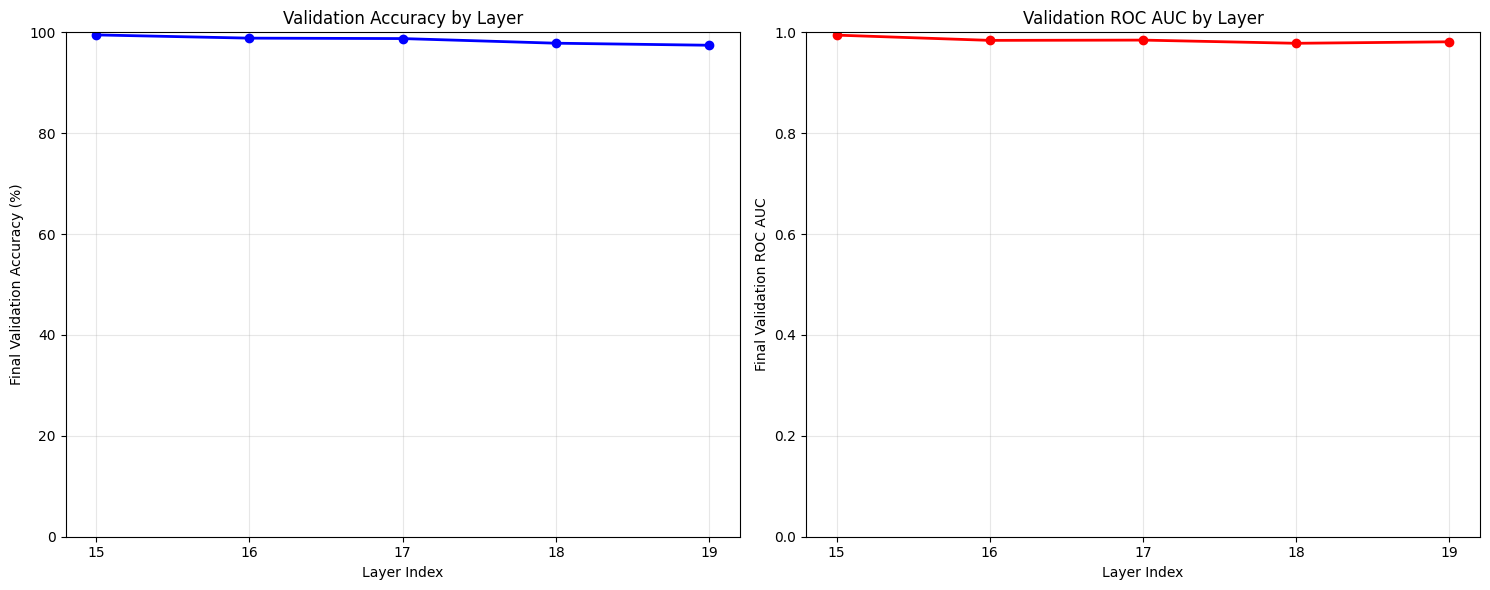

In [64]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot validation accuracy by layer
ax1.plot(results_df['layer_idx'], results_df['final_val_accuracy'], 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Layer Index')
ax1.set_ylabel('Final Validation Accuracy (%)')
ax1.set_title('Validation Accuracy by Layer')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(results_df['layer_idx'])
ax1.set_ylim(0, 100)

# Plot validation ROC AUC by layer
ax2.plot(results_df['layer_idx'], results_df['final_val_roc_auc'], 'r-o', linewidth=2, markersize=6)
ax2.set_xlabel('Layer Index')
ax2.set_ylabel('Final Validation ROC AUC')
ax2.set_title('Validation ROC AUC by Layer')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(results_df['layer_idx'])
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()


In [58]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.6/111.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 37.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 54.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.7 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip
